## Prac 07.1
In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

In [117]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?

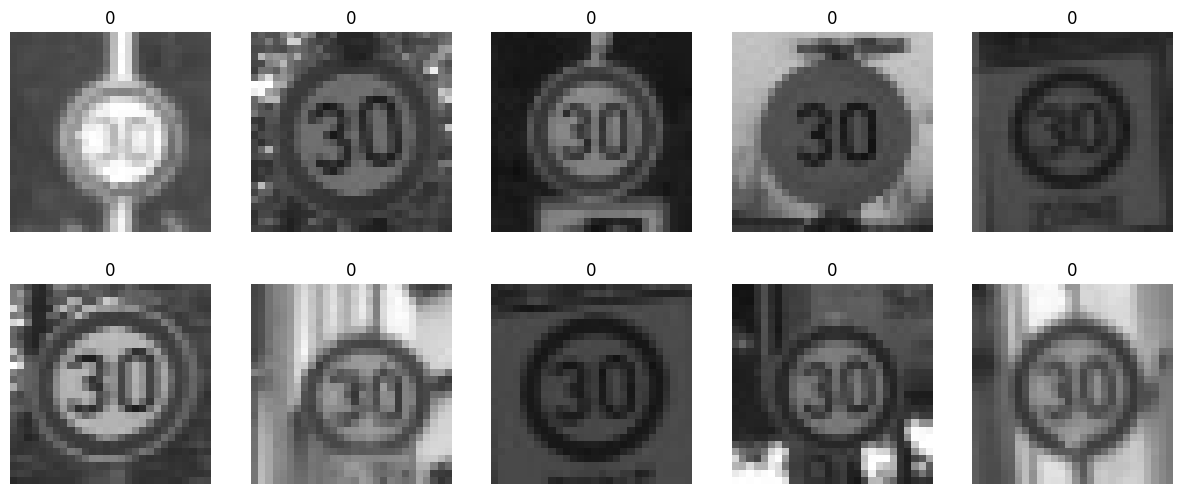

In [118]:
folder = 'data/subset_homework'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

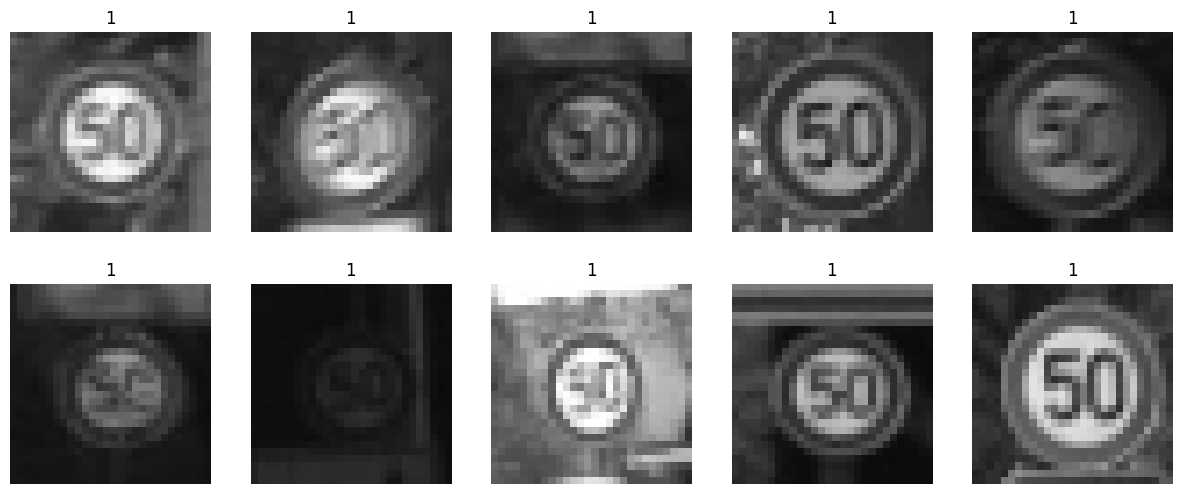

In [119]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [120]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

pixels = np.array([image.flatten() for image in images])/255

print('Images', images.shape)
print('Labels', labels.shape)
print('Shape', pixels.shape)

Images (4470, 28, 28)
Labels (4470,)
Shape (4470, 784)


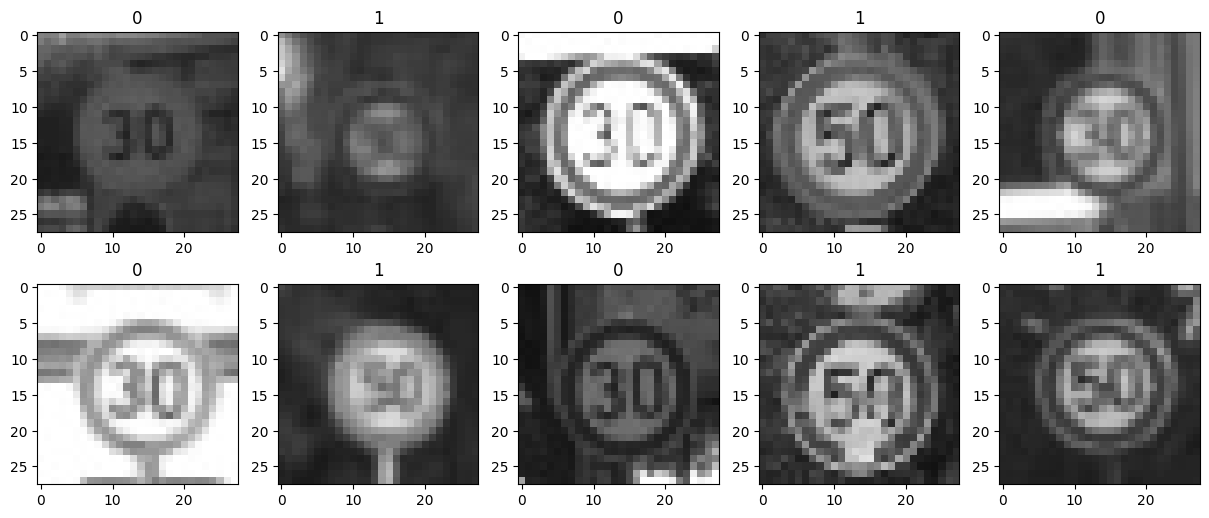

In [121]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?

In [122]:
labels_train = labels[:labels.shape[0]*7//10]
labels_test = labels[labels.shape[0]*7//10:]
pixels_train = pixels[:pixels.shape[0]*7//10]
pixels_test = pixels[pixels.shape[0]*7//10:]
images_train = images[:images.shape[0]*7//10]
images_test = images[images.shape[0]*7//10:]
print(np.count_nonzero(labels_train)*100/len(labels_train), "% of class 1 in train dataset")

50.39948865452221 % of class 1 in train dataset


In [123]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

In [124]:
input_layer = Input(shape=(pixels.shape[1],))

x = Dense(10, activation="linear")(input_layer)
output_layer = Dense(2, activation="softmax")(x)

model = Model(input_layer, output_layer)
model.summary()

Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 784)]             0         
                                                                 
 dense_40 (Dense)            (None, 10)                7850      
                                                                 
 dense_41 (Dense)            (None, 2)                 22        
                                                                 
Total params: 7,872
Trainable params: 7,872
Non-trainable params: 0
_________________________________________________________________


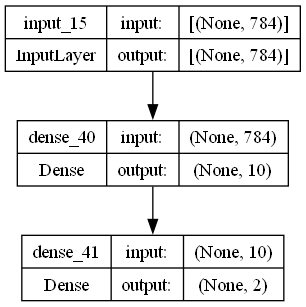

In [125]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

In [126]:
optimizer = Adam(learning_rate = 0.0001)
model.compile(optimizer = optimizer, loss = tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics="accuracy")

In [127]:
early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, monitor="loss", restore_best_weights=True)
history = model.fit(pixels_train, labels_train, epochs=100, batch_size=16, callbacks=[early_stopping])

Epoch 1/100
196/196 [==============================] - 1s 2ms/step - loss: 0.7214 - accuracy: 0.5379
Epoch 2/100
196/196 [==============================] - 0s 1ms/step - loss: 0.6508 - accuracy: 0.6433
Epoch 3/100
196/196 [==============================] - 0s 2ms/step - loss: 0.6210 - accuracy: 0.6894
Epoch 4/100
196/196 [==============================] - 0s 2ms/step - loss: 0.5939 - accuracy: 0.7057
Epoch 5/100
196/196 [==============================] - 0s 2ms/step - loss: 0.5696 - accuracy: 0.7395
Epoch 6/100
196/196 [==============================] - 0s 2ms/step - loss: 0.5490 - accuracy: 0.7648
Epoch 7/100
196/196 [==============================] - 0s 1ms/step - loss: 0.5305 - accuracy: 0.7731
Epoch 8/100
196/196 [==============================] - 0s 2ms/step - loss: 0.5062 - accuracy: 0.8028
Epoch 9/100
196/196 [==============================] - 0s 1ms/step - loss: 0.4870 - accuracy: 0.8137
Epoch 10/100
196/196 [==============================] - 0s 2ms/step - loss: 0.4681 - accura

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

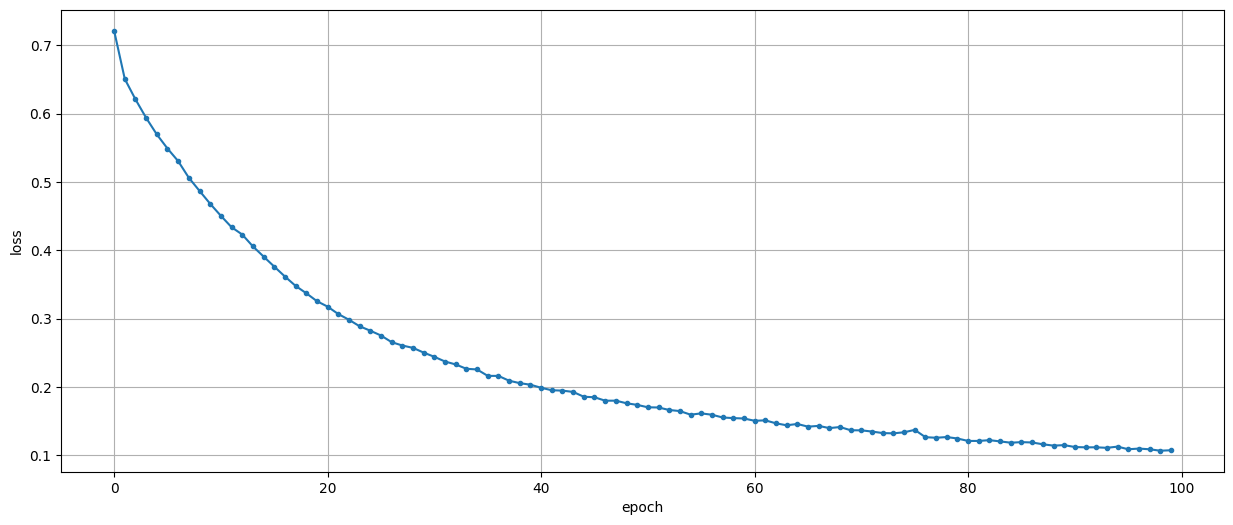

In [128]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [129]:
model.evaluate(pixels_train, labels_train)
model.evaluate(pixels_test, labels_test)

42/42 [==============================] - 0s 1ms/step - loss: 0.1300 - accuracy: 0.9523


[0.12997491657733917, 0.9522744417190552]

### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?

Модель з активаційною функцією relu, більшою кількістю шарів та з дропаут:

In [130]:
input_layer = Input(shape=(pixels.shape[1],))

x = Dense(10, activation="linear")(input_layer)
x = Dropout(0.3)(x)
x = Dense(100, activation="linear")(x)
x = Dropout(0.3)(x)
x = Dense(100, activation="linear")(x)
x = Dropout(0.3)(x)
output_layer = Dense(2, activation="softmax")(x)

model = Model(input_layer, output_layer)
model.summary()

Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 784)]             0         
                                                                 
 dense_42 (Dense)            (None, 10)                7850      
                                                                 
 dropout_22 (Dropout)        (None, 10)                0         
                                                                 
 dense_43 (Dense)            (None, 100)               1100      
                                                                 
 dropout_23 (Dropout)        (None, 100)               0         
                                                                 
 dense_44 (Dense)            (None, 100)               10100     
                                                                 
 dropout_24 (Dropout)        (None, 100)               0  

In [131]:
model.compile(optimizer ='adam', loss = tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics="accuracy")
history = model.fit(pixels_train, labels_train, epochs=50, batch_size=16, callbacks = [early_stopping])

Epoch 1/50
196/196 [==============================] - 1s 2ms/step - loss: 0.6908 - accuracy: 0.5887
Epoch 2/50
196/196 [==============================] - 0s 2ms/step - loss: 0.5881 - accuracy: 0.6938
Epoch 3/50
196/196 [==============================] - 0s 2ms/step - loss: 0.4710 - accuracy: 0.7983
Epoch 4/50
196/196 [==============================] - 0s 2ms/step - loss: 0.3976 - accuracy: 0.8341
Epoch 5/50
196/196 [==============================] - 0s 2ms/step - loss: 0.3357 - accuracy: 0.8623
Epoch 6/50
196/196 [==============================] - 0s 2ms/step - loss: 0.3255 - accuracy: 0.8811
Epoch 7/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2573 - accuracy: 0.9032
Epoch 8/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2722 - accuracy: 0.8945
Epoch 9/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2669 - accuracy: 0.9057
Epoch 10/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2053 - accuracy: 0.9265

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

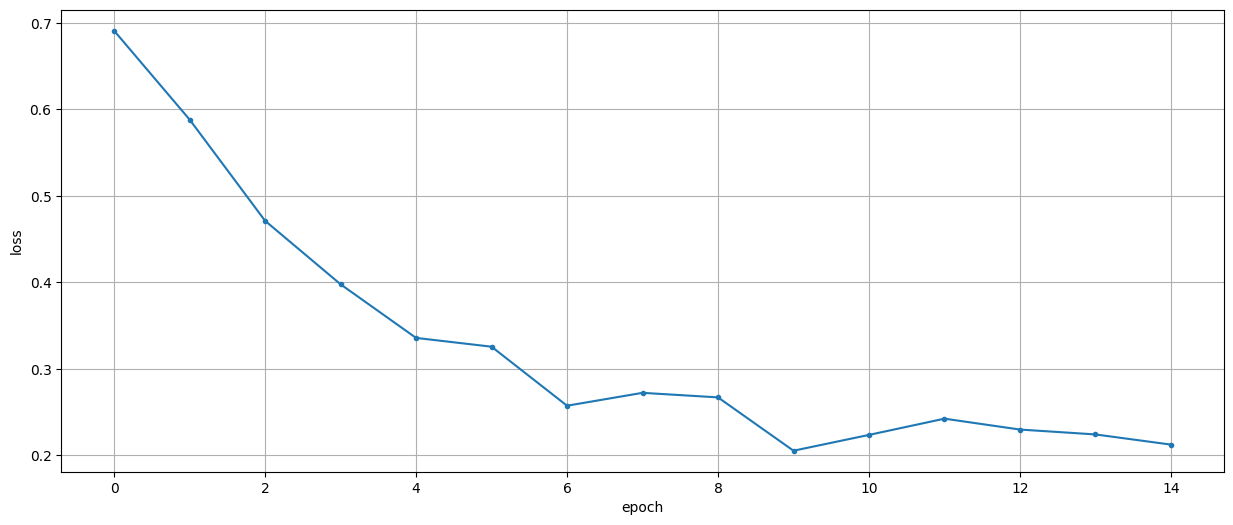

In [132]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [133]:
model.evaluate(pixels_train, labels_train)
model.evaluate(pixels_test, labels_test)

42/42 [==============================] - 0s 1ms/step - loss: 0.1688 - accuracy: 0.9374


[0.1687835305929184, 0.9373601675033569]

Згорткова нейронна мережа:

In [134]:
input_layer = Input(shape=(images_train.shape[1], images_train.shape[2], 1))

x = Conv2D(3, (3,3), activation="linear")(input_layer)
x = MaxPooling2D(2,2)(x)
x = Conv2D(6,(3, 3), activation="linear")(x)
x = MaxPooling2D(2,2)(x)
x = Conv2D(18,(3, 3), activation="linear")(x)
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(10, activation="linear")(x)
x = Dropout(0.3)(x)
output_layer = Dense(2, activation="softmax")(x)

model = Model(input_layer, output_layer)
model.summary()

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 26, 26, 3)         30        
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 3)        0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 11, 11, 6)         168       
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 5, 5, 6)          0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 3, 3, 18)          990

In [135]:
model.compile(optimizer ='adam', loss = tf.losses.SparseCategoricalCrossentropy(from_logits=False), metrics="accuracy")
history = model.fit(images_train, labels_train, epochs=50, batch_size=16, callbacks=[early_stopping])

Epoch 1/50
196/196 [==============================] - 1s 2ms/step - loss: 6.9725 - accuracy: 0.6446
Epoch 2/50
196/196 [==============================] - 0s 2ms/step - loss: 1.5297 - accuracy: 0.8118
Epoch 3/50
196/196 [==============================] - 0s 2ms/step - loss: 0.9153 - accuracy: 0.8667
Epoch 4/50
196/196 [==============================] - 0s 2ms/step - loss: 0.6352 - accuracy: 0.8881
Epoch 5/50
196/196 [==============================] - 0s 2ms/step - loss: 0.4571 - accuracy: 0.9118
Epoch 6/50
196/196 [==============================] - 0s 2ms/step - loss: 0.3507 - accuracy: 0.9217
Epoch 7/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2983 - accuracy: 0.9255
Epoch 8/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2529 - accuracy: 0.9354
Epoch 9/50
196/196 [==============================] - 0s 2ms/step - loss: 0.2222 - accuracy: 0.9345
Epoch 10/50
196/196 [==============================] - 0s 2ms/step - loss: 0.1980 - accuracy: 0.9409

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

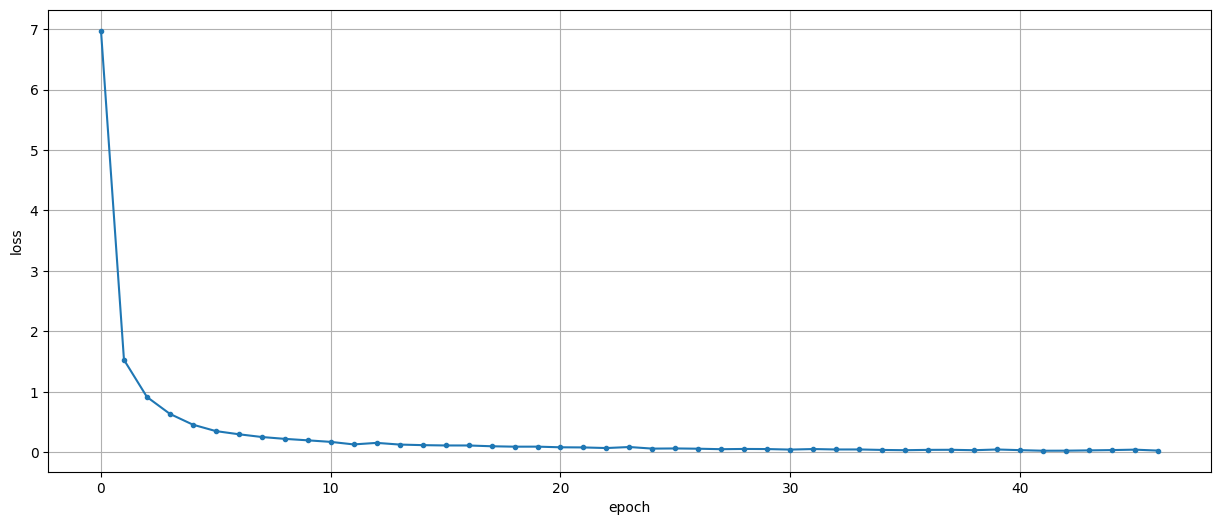

In [136]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [138]:
model.evaluate(images_train, labels_train)
model.evaluate(images_test, labels_test)

42/42 [==============================] - 0s 2ms/step - loss: 0.0778 - accuracy: 0.9821


[0.07783803343772888, 0.9821029305458069]